# 04 · Features and Exploratory Analysis

**PRT661 Assessment 2 · Group 4 · DKASC Alice Springs**
**Owners: Sarin Uprety (features) · Yogesh Basnet (EDA and figures)**

Builds the modelling feature set from `mastermeter1_hourly_clean.parquet` and produces the
exploratory figures cited in the report.

Feature families:

* **Solar geometry** — solar elevation and a Haurwitz clear sky irradiance estimate, from site
  latitude and longitude. Physics, not learned, so it costs no data.
* **Clear sky index** — measured irradiance divided by clear sky irradiance, isolating the cloud
  signal from the daily and seasonal cycle.
* **Calendar** — cyclical sine and cosine encodings, so hour 23 sits next to hour 0.
* **Lags and rolling statistics** — target and irradiance at t-1, t-2, t-3, t-24 and t-168.
  Backward looking only.
* **Degradation** — years elapsed since commissioning.

Writes `Datasets/processed/features_hourly.parquet` and figures to `Outputs/figures/`.
Figures display inline as well as being saved.

In [23]:
%matplotlib inline
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

REPO = Path("/Users/uttamshrestha/Desktop/Data Science Practice Unit/PRT661-solar-forecasting")
PROC, OUT = REPO/"Datasets"/"processed", REPO/"Outputs"
FIG = OUT/"figures"; FIG.mkdir(parents=True, exist_ok=True)

TARGET = "Active_Power"
LAT, LON, TZ = -23.762, 133.874, 9.5      # DKASC Alice Springs, ACST

h = pd.read_parquet(PROC/"mastermeter1_hourly_clean.parquet")
print(f"{len(h):,} hourly rows, {h[TARGET].notna().sum():,} with target")
print(f"{h.index.min()} to {h.index.max()}")

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9,
                     "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

148,537 hourly rows, 147,134 with target
2008-09-12 05:00:00 to 2025-08-23 05:00:00


## 1 · Solar geometry and clear sky irradiance

Solar elevation from declination, the equation of time and the hour angle. Clear sky global
horizontal irradiance uses the Haurwitz model, which depends only on solar zenith angle.

The printed check matters: if the timestamps are local ACST, mean generation must peak within an
hour of solar noon. A peak at the wrong hour means the timestamps are UTC and every lag feature
would be misaligned by nine and a half hours.

In [24]:
idx = h.index
doy  = idx.dayofyear.values.astype(float)
hod  = idx.hour.values.astype(float)

decl = np.radians(23.45*np.sin(2*np.pi*(284+doy)/365))
B    = 2*np.pi*(doy-81)/364
eot  = 9.87*np.sin(2*B) - 7.53*np.cos(B) - 1.5*np.sin(B)
solar_time = hod + 0.5 + (4*(LON - 15*TZ) + eot)/60      # +0.5 = hour bin centre
ha   = np.radians(15*(solar_time - 12))

lat = np.radians(LAT)
sin_elev = np.clip(np.sin(lat)*np.sin(decl) + np.cos(lat)*np.cos(decl)*np.cos(ha), -1, 1)
elev = np.degrees(np.arcsin(sin_elev))

cos_z  = np.clip(sin_elev, 1e-3, 1)
ghi_cs = np.where(elev > 0, 1098*cos_z*np.exp(-0.059/cos_z), 0.0)

f = pd.DataFrame(index=idx)
f["solar_elevation"] = elev
f["ghi_clearsky"]    = ghi_cs
f["is_daylight"]     = (elev > 0).astype(int)
f["clearsky_index"]  = np.where(ghi_cs > 20, h["Global_Horizontal_Radiation"]/ghi_cs, np.nan)
f["clearsky_index"]  = f["clearsky_index"].clip(0, 1.5)

chk = h[TARGET].groupby(idx.hour).mean()
print(f"peak generation hour: {chk.idxmax()}   (expect 11 to 13 if timestamps are local ACST)")
print(f"peak clear sky hour : {pd.Series(ghi_cs, index=idx).groupby(idx.hour).mean().idxmax()}")
print()
print("mean generation by hour of day:")
print(chk.round(1).to_string())

peak generation hour: 12   (expect 11 to 13 if timestamps are local ACST)
peak clear sky hour : 12

mean generation by hour of day:
timestamp
0      -0.5
1      -0.5
2      -0.5
3      -0.5
4      -0.5
5      -0.5
6       2.1
7      21.8
8      64.9
9     101.5
10    126.2
11    139.5
12    143.1
13    138.9
14    126.1
15    104.8
16     73.8
17     32.6
18      4.3
19     -0.4
20     -0.5
21     -0.5
22     -0.5
23     -0.5


## 2 · Calendar, lag, rolling and degradation features

Every lag is backward looking. Nothing here uses information unavailable at the moment a forecast would be made.

In [25]:
f["hour_sin"] = np.sin(2*np.pi*hod/24);  f["hour_cos"] = np.cos(2*np.pi*hod/24)
f["doy_sin"]  = np.sin(2*np.pi*doy/365); f["doy_cos"]  = np.cos(2*np.pi*doy/365)
f["years_since_start"] = (idx - idx.min()).total_seconds()/(365.25*24*3600)

BASE = ["Global_Horizontal_Radiation", "Diffuse_Horizontal_Radiation",
        "Weather_Temperature_Celsius", "Weather_Relative_Humidity"]
for c in BASE:
    if c in h.columns:
        f[c] = h[c]

for lag in [1, 2, 3, 24, 168]:
    f[f"target_lag{lag}"] = h[TARGET].shift(lag)
for lag in [1, 2, 24]:
    f[f"ghi_lag{lag}"] = h["Global_Horizontal_Radiation"].shift(lag)
    f[f"csi_lag{lag}"] = f["clearsky_index"].shift(lag)

for w in [3, 24, 168]:
    f[f"target_roll{w}"] = h[TARGET].shift(1).rolling(w, min_periods=max(2, w//4)).mean()
f["csi_roll24"]   = f["clearsky_index"].shift(1).rolling(24, min_periods=6).mean()
f["target_std24"] = h[TARGET].shift(1).rolling(24, min_periods=6).std()

f["y"] = h[TARGET]
f["n_obs"] = h["n_obs"]

print(f"{f.shape[1]-2} features, {len(f):,} rows\n")
print(pd.DataFrame({"missing_%": (100*f.isna().mean()).round(2)}).to_string())
print("\nclearsky_index is missing at night by construction, not by fault:")
print(f"   night hours: {int((f['is_daylight'] == 0).sum()):,} "
      f"({100*(f['is_daylight'] == 0).mean():.1f}% of rows)")

29 features, 148,537 rows

                              missing_%
solar_elevation                    0.00
ghi_clearsky                       0.00
is_daylight                        0.00
clearsky_index                    52.56
hour_sin                           0.00
hour_cos                           0.00
doy_sin                            0.00
doy_cos                            0.00
years_since_start                  0.00
Global_Horizontal_Radiation        1.63
Diffuse_Horizontal_Radiation       1.63
Weather_Temperature_Celsius        1.80
Weather_Relative_Humidity          2.27
target_lag1                        0.94
target_lag2                        0.95
target_lag3                        0.95
target_lag24                       0.96
target_lag168                      1.06
ghi_lag1                           1.63
csi_lag1                          52.56
ghi_lag2                           1.64
csi_lag2                          52.56
ghi_lag24                          1.65
csi_lag24    

## 3 · Figure 1 · Generation history, build-out and degradation

**The trend is fitted from 2014 only.** From 2009 to 2013 the site was still being commissioned,
so output rises as arrays are added. Fitting across that period would produce a positive trend
and a chart labelled "degradation" showing generation increasing. The build-out years are shown
as open markers for honesty, but the degradation rate is measured only over the stable array.

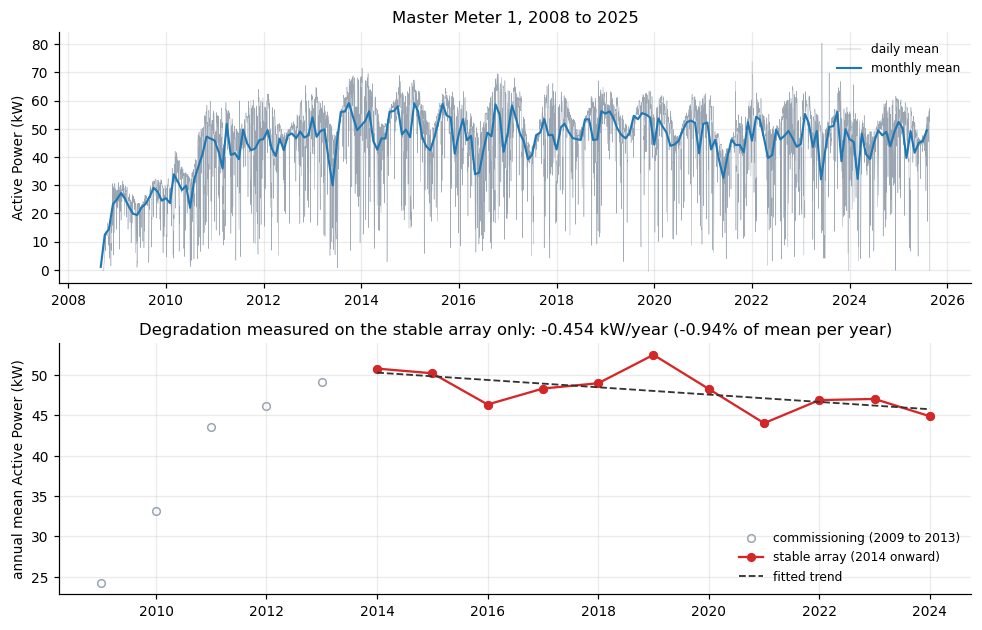

trend fitted 2009 to 2024 (WRONG, includes build-out): +0.748 kW/year
trend fitted 2014 to 2024 (stable array)          : -0.454 kW/year (-0.94%/yr)

annual means:
timestamp
2009-01-01    24.25
2010-01-01    33.16
2011-01-01    43.53
2012-01-01    46.21
2013-01-01    49.08
2014-01-01    50.80
2015-01-01    50.22
2016-01-01    46.35
2017-01-01    48.33
2018-01-01    48.98
2019-01-01    52.50
2020-01-01    48.28
2021-01-01    44.04
2022-01-01    46.90
2023-01-01    47.04
2024-01-01    44.89
Freq: YS-JAN


In [26]:
STABLE_FROM = 2014

daily   = h[TARGET].resample("1D").mean()
monthly = h[TARGET].resample("MS").mean()
annual  = h[TARGET].resample("YS").mean()

yr_all = annual[annual.index.year.isin(range(2009, 2025))]
yr     = annual[annual.index.year.isin(range(STABLE_FROM, 2025))]

fig, ax = plt.subplots(2, 1, figsize=(9, 5.8))
ax[0].plot(daily.index, daily.values, lw=.3, color="#9aa5b1", label="daily mean")
ax[0].plot(monthly.index, monthly.values, lw=1.4, color="#1f77b4", label="monthly mean")
ax[0].set_ylabel("Active Power (kW)")
ax[0].set_title("Master Meter 1, 2008 to 2025")
ax[0].legend(frameon=False, fontsize=8)

ax[1].plot(yr_all.index, yr_all.values, "o", mfc="none", ms=5, color="#9aa5b1",
           label=f"commissioning (2009 to {STABLE_FROM-1})")
ax[1].plot(yr.index, yr.values, "o-", color="#d62728", lw=1.5, ms=5,
           label=f"stable array ({STABLE_FROM} onward)")
x = np.arange(len(yr)); z = np.polyfit(x, yr.values, 1)
ax[1].plot(yr.index, np.poly1d(z)(x), "--", color="#333", lw=1.2, label="fitted trend")
ax[1].set_ylabel("annual mean Active Power (kW)")
ax[1].set_title(f"Degradation measured on the stable array only: {z[0]:+.3f} kW/year "
                f"({100*z[0]/yr.values.mean():+.2f}% of mean per year)")
ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG/"fig1_generation_history.png")
plt.show()

z_all = np.polyfit(np.arange(len(yr_all)), yr_all.values, 1)
print(f"trend fitted 2009 to 2024 (WRONG, includes build-out): {z_all[0]:+.3f} kW/year")
print(f"trend fitted {STABLE_FROM} to 2024 (stable array)          : {z[0]:+.3f} kW/year "
      f"({100*z[0]/yr.values.mean():+.2f}%/yr)")
print()
print("annual means:")
print(yr_all.round(2).to_string())

## 4 · Figure 2 · Diurnal profile by season, and the ramp problem

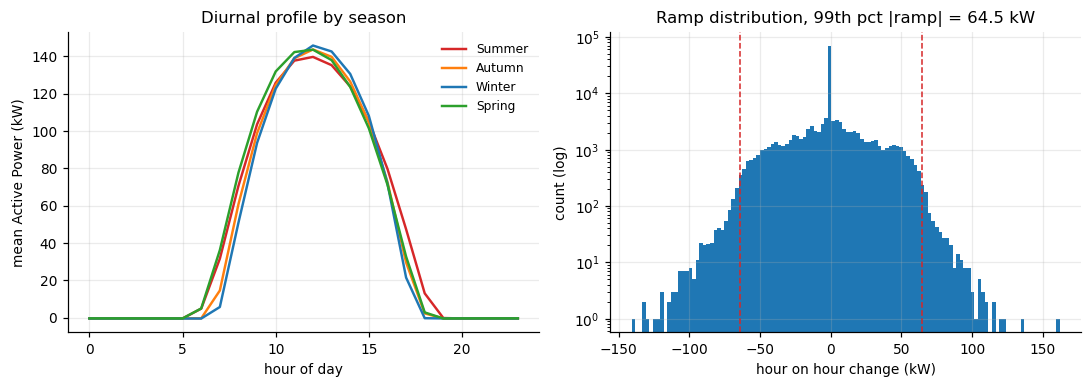

ramp events above the 99th percentile (64.5 kW): 1,470
largest positive ramp: +162.1 kW
largest negative ramp: -140.8 kW


In [27]:
seasons = {12:"Summer",1:"Summer",2:"Summer",3:"Autumn",4:"Autumn",5:"Autumn",
           6:"Winter",7:"Winter",8:"Winter",9:"Spring",10:"Spring",11:"Spring"}
s = pd.Series([seasons[m] for m in idx.month], index=idx)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for name, col in zip(["Summer","Autumn","Winter","Spring"],
                     ["#d62728","#ff7f0e","#1f77b4","#2ca02c"]):
    m = s == name
    prof = h.loc[m, TARGET].groupby(h.index[m].hour).mean()
    ax[0].plot(prof.index, prof.values, color=col, lw=1.6, label=name)
ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("mean Active Power (kW)")
ax[0].set_title("Diurnal profile by season"); ax[0].legend(frameon=False, fontsize=8)

ramp = h[TARGET].diff()
p99 = ramp.abs().quantile(0.99)
ax[1].hist(ramp.dropna(), bins=120, color="#1f77b4", log=True)
ax[1].axvline( p99, ls="--", c="#d62728", lw=1); ax[1].axvline(-p99, ls="--", c="#d62728", lw=1)
ax[1].set_xlabel("hour on hour change (kW)"); ax[1].set_ylabel("count (log)")
ax[1].set_title(f"Ramp distribution, 99th pct |ramp| = {p99:.1f} kW")
fig.tight_layout()
fig.savefig(FIG/"fig2_diurnal_and_ramps.png")
plt.show()

print(f"ramp events above the 99th percentile ({p99:.1f} kW): {int((ramp.abs() > p99).sum()):,}")
print(f"largest positive ramp: {ramp.max():+.1f} kW")
print(f"largest negative ramp: {ramp.min():+.1f} kW")

## 5 · Figure 3 · Correlation with the target, daylight hours only

Night hours are excluded: a correlation dominated by a shared zero says nothing about forecasting skill.

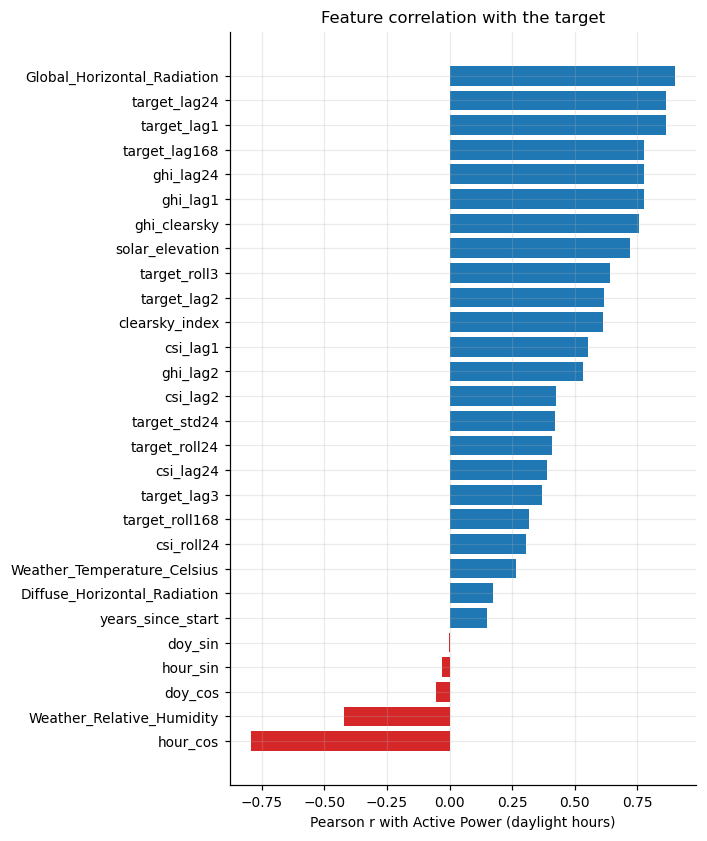

strongest absolute correlations (daylight hours):
Global_Horizontal_Radiation    0.900
target_lag24                   0.863
target_lag1                    0.862
hour_cos                      -0.793
target_lag168                  0.776
ghi_lag24                      0.776
ghi_lag1                       0.774
ghi_clearsky                   0.758
solar_elevation                0.720
target_roll3                   0.638
target_lag2                    0.616
clearsky_index                 0.613


In [28]:
day  = f[f["is_daylight"] == 1]
num  = day.select_dtypes("number").drop(columns=["is_daylight", "n_obs"], errors="ignore")
corr = num.corr()["y"].drop("y").sort_values()

fig, ax = plt.subplots(figsize=(6.5, 0.24*len(corr)+1))
ax.barh(corr.index, corr.values,
        color=["#d62728" if v < 0 else "#1f77b4" for v in corr.values])
ax.set_xlabel("Pearson r with Active Power (daylight hours)")
ax.set_title("Feature correlation with the target")
fig.tight_layout()
fig.savefig(FIG/"fig3_correlations.png")
plt.show()

print("strongest absolute correlations (daylight hours):")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).head(12).round(3).to_string())

## 6 · Write the feature store and the feature dictionary

In [29]:
fp = PROC/"features_hourly.parquet"
f.to_parquet(fp, compression="snappy")
print(f"{fp.name}: {fp.stat().st_size/1e6:.1f} MB, {len(f):,} rows, {f.shape[1]} columns")
print(f"rows with a target value            : {len(f.dropna(subset=['y'])):,}")
print(f"rows with target and all lag features: "
      f"{len(f.dropna(subset=['y','target_lag1','target_lag24','target_lag168'])):,}")

lines = ["# Feature Dictionary", "",
         "Generated by `notebooks/04_features_and_eda.ipynb`.",
         f"Source: `mastermeter1_hourly_clean.parquet`. {len(f):,} hourly rows, "
         f"{f.index.min()} to {f.index.max()}.", "",
         "| Feature | Family | Definition |", "|---|---|---|",
         "| `solar_elevation` | geometry | Solar elevation angle in degrees, from declination, equation of time and hour angle |",
         "| `ghi_clearsky` | geometry | Haurwitz clear sky global horizontal irradiance, W/m2 |",
         "| `is_daylight` | geometry | 1 where solar elevation exceeds 0 |",
         "| `clearsky_index` | cloud | Measured GHI divided by clear sky GHI, clipped to 0 to 1.5. Undefined at night by construction |",
         "| `hour_sin`, `hour_cos` | calendar | Cyclical encoding of hour of day |",
         "| `doy_sin`, `doy_cos` | calendar | Cyclical encoding of day of year |",
         "| `years_since_start` | degradation | Years elapsed since first reading |",
         "| `target_lag{1,2,3,24,168}` | lag | Active Power at t minus n hours |",
         "| `ghi_lag{1,2,24}` | lag | Global horizontal radiation at t minus n hours |",
         "| `csi_lag{1,2,24}` | lag | Clear sky index at t minus n hours |",
         "| `target_roll{3,24,168}` | rolling | Mean Active Power over the preceding n hours |",
         "| `csi_roll24` | rolling | Mean clear sky index over the preceding 24 hours |",
         "| `target_std24` | rolling | Standard deviation of Active Power over the preceding 24 hours |",
         "", "All lag and rolling features are shifted so that no value at time t uses information",
         "recorded at or after t. `y` is the contemporaneous target and is never used as an input.", "",
         f"Degradation is measured on the stable array from {STABLE_FROM} onward. Years 2009 to "
         f"{STABLE_FROM-1} are the site build-out period, during which rising output reflects "
         "arrays being commissioned rather than any change in panel performance."]
(REPO/"Supporting_Documents"/"feature-dictionary.md").write_text("\n".join(lines))
print("\nwrote Supporting_Documents/feature-dictionary.md")

features_hourly.parquet: 31.1 MB, 148,537 rows, 31 columns
rows with a target value            : 147,134
rows with target and all lag features: 145,243

wrote Supporting_Documents/feature-dictionary.md
